<a href="https://colab.research.google.com/github/tisha1010/Machine-Vision/blob/main/MACHINE_VISION_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

practical 5

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Accuracy of KNN classifier on CIFAR-10 (small subset): 25.00%


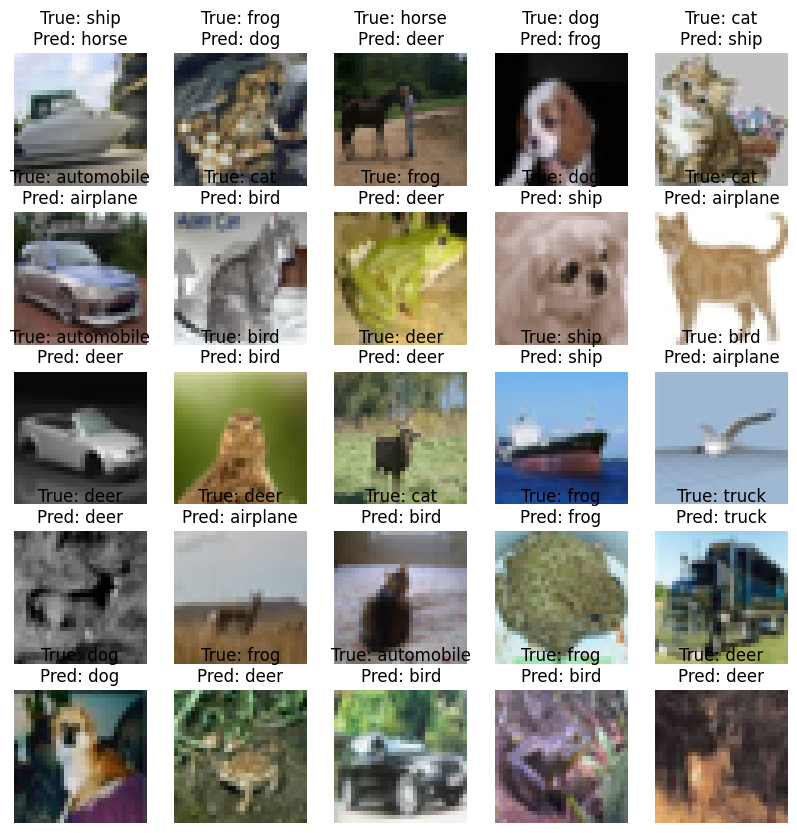

In [ ]:
##KNN for object recognizion of image(KK)
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

# Step 1: Load the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Flatten the labels to 1D
y_train = y_train.flatten()
y_test = y_test.flatten()

# Step 2: Preprocess the images (flatten 32x32x3 into 1D array of 3072 features)
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Normalize the data to range [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Optional: You can reduce the size of the dataset for faster computation
X_train_small, _, y_train_small, _ = train_test_split(X_train, y_train, test_size=0.9, random_state=42)
X_test_small, _, y_test_small, _ = train_test_split(X_test, y_test, test_size=0.9, random_state=42)

# Step 3: Implement the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)  # Use n_jobs=-1 to parallelize computation

# Step 4: Train the KNN model
knn.fit(X_train_small, y_train_small)

# Step 5: Predict on the test set
y_pred = knn.predict(X_test_small)

# Step 6: Evaluate the model's performance
accuracy = accuracy_score(y_test_small, y_pred)
print(f'Accuracy of KNN classifier on CIFAR-10 (small subset): {accuracy * 100:.2f}%')

# Step 7: Visualize some predictions
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def plot_cifar10(images, labels, predictions=None):
    plt.figure(figsize=(10, 10))
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].reshape(32, 32, 3))
        if predictions is None:
            plt.title(f"Label: {class_names[labels[i]]}")
        else:
            plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[predictions[i]]}")
        plt.axis('off')
    plt.show()

# Display a few images and their predictions
plot_cifar10(X_test_small[:25], y_test_small[:25], y_pred[:25])




Modified KNN


In [ ]:
import numpy as np
import cv2
import glob
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Path to dataset (modify as needed)
DATASET_PATH = "data/"

# Function to load images and labels
def load_data():
    X, y, class_names = [], [], []

    # Get folder names (categories)
    folders = glob.glob(f"{DATASET_PATH}*/")  # Gets subdirectories
    class_names = [folder.split("/")[-2] for folder in folders]  # Extract category names

    # Process images
    for i in range(len(folders)):
        images = glob.glob(folders[i] + "*.jpg")  # Get all .jpg images
        for img_path in images:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (32, 32))
            X.append(img.flatten())  # Convert image to 1D array
            y.append(i)  # Use index as label

    return np.array(X), np.array(y), class_names

# Load dataset
X, y, class_names = load_data()

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Function to show sample predictions
def show_predictions():
    plt.figure(figsize=(10, 10))
    for i in range(min(9, len(X_test))):
        img = X_test[i].reshape(32, 32, 3)
        plt.subplot(3, 3, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"True: {class_names[y_test[i]]}\nPred: {class_names[y_pred[i]]}")
        plt.axis('off')
    plt.show()

# Display some test images and predictions
show_predictions()


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
from google.colab.patches import cv2_imshow

Predicted Object: Rectangle


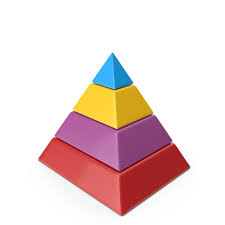

In [ ]:
import cv2
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from google.colab.patches import cv2_imshow

# Load the image
image = cv2.imread("tri.png")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply threshold
_, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Prepare dataset
X, y = [], []
labels = ["Circle", "Rectangle", "Triangle"]  # Example labels

for cnt in contours:
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    if area > 0 and perimeter > 0:  # Avoid zero-area/perimeter cases
        X.append([area, perimeter])
        y.append(np.random.choice(labels))  # Replace with actual labels

# Check if we have enough data to train
if len(X) > 0:
    # Train KNN classifier
    knn = KNeighborsClassifier(n_neighbors=min(3, len(X)))  # Ensure valid k value
    knn.fit(X, y)

    # Test on a new object (dummy data)
    test_object = [[2000, 150]]  # Example area and perimeter
    prediction = knn.predict(test_object)
    print("Predicted Object:", prediction[0])
else:
    print("No objects found in the image.")

cv2_imshow(image)
cv2.waitKey(0)
cv2.destroyAllWindows()


practical 6

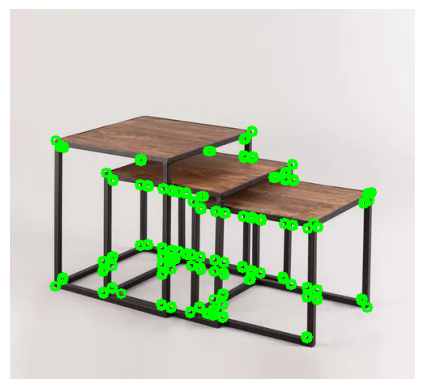

In [ ]:
############  corner detection
import cv2
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread("img2.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

corners = cv2.cornerHarris(gray, 2, 3, 0.04)
corners = cv2.dilate(corners, None) #for visibility

# Draw circles around detected corners
threshold = 0.01 * corners.max()
for y in range(corners.shape[0]):
  for x in range(corners.shape[1]):
    if corners[y, x] > threshold:
      cv2.circle(image, (x, y), 5, (0, 255, 0), 1)  # Green circle with thickness 1

plt.axis("off")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()



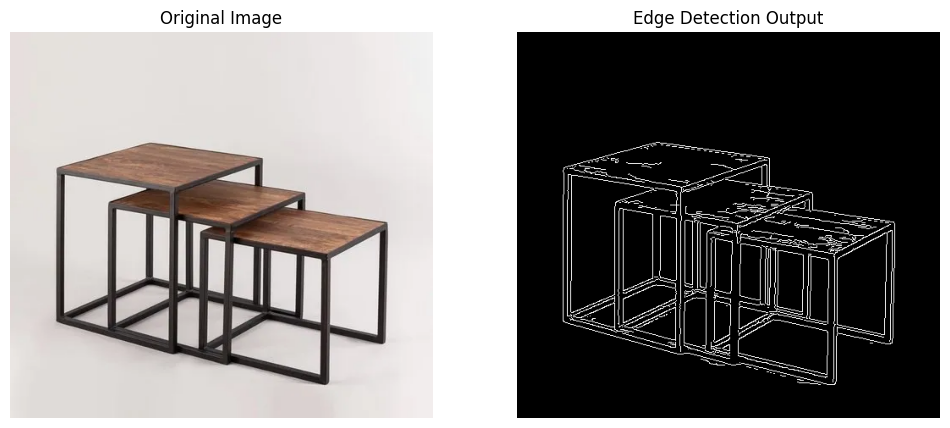

In [ ]:
########  edge detectionnn
import cv2
import matplotlib.pyplot as plt
import numpy as np
image_path = "img2.jpg"
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Apply edge detection
edges = cv2.Canny(gray, 50, 150, apertureSize=3)
# Display the original and edge-detected images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")
axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Edge Detection Output")
axes[1].axis("off")
plt.show()

practical 7

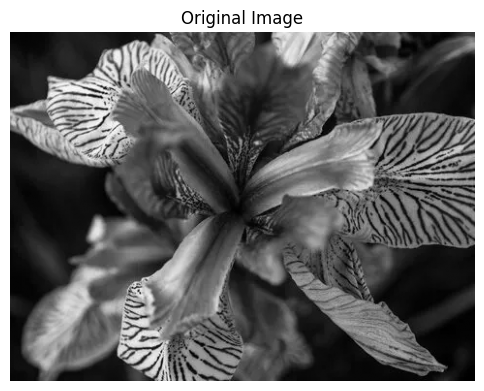

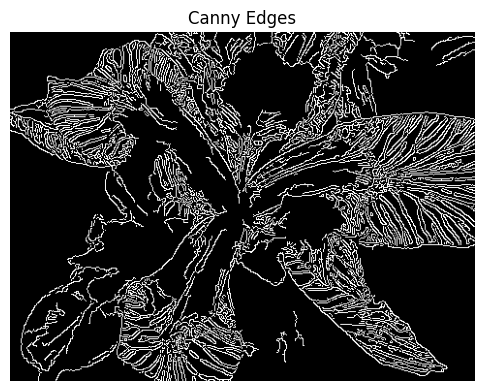

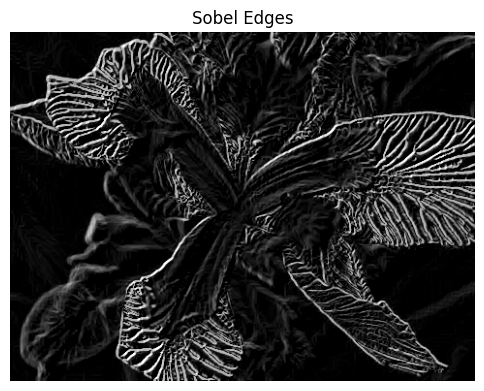

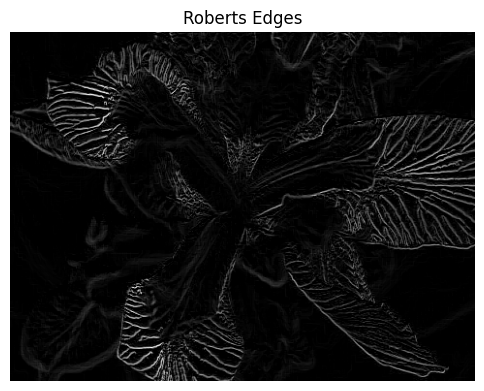

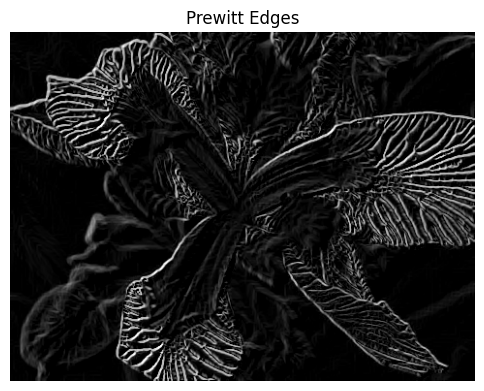

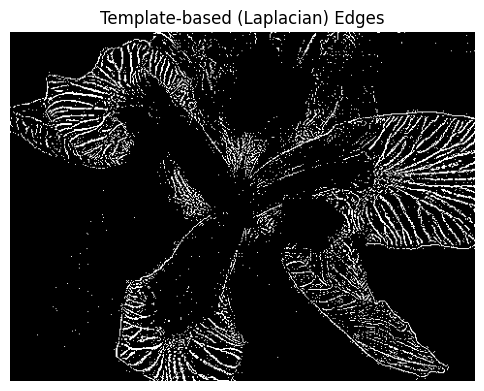

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Load the image in grayscale
image = cv2.imread("img1.jpg", cv2.IMREAD_GRAYSCALE)

# Function to display images
def display_results(title, img):
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# a. Canny Edge Detection
def canny_edges(img, low=50, high=150):
    return cv2.Canny(img, low, high)

# b. Derivative-based Edge Detection
def derivative_edges(img, operator='sobel'):
    kernels = {
        'robert': {
            'x': np.array([[1, 0], [0, -1]]),
            'y': np.array([[0, 1], [-1, 0]])
        },
        'sobel': {
            'x': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
            'y': np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
        },
        'prewitt': {
            'x': np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]),
            'y': np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
        }
    }

    kx = kernels[operator]['x']
    ky = kernels[operator]['y']

    gx = cv2.filter2D(img, -1, kx)
    gy = cv2.filter2D(img, -1, ky)

    return np.hypot(gx, gy)  # Magnitude combination

# c. Template-based Edge Detection (Laplacian Filter)
def template_edges(img):
    kernel = np.array([[0, 1, 0],
                       [1, -4, 1],
                       [0, 1, 0]])

    filtered = cv2.filter2D(img, -1, kernel)
    return cv2.threshold(np.abs(filtered), 30, 255, cv2.THRESH_BINARY)[1]

# Apply and display results
display_results("Original Image", image)
display_results("Canny Edges", canny_edges(image))
display_results("Sobel Edges", derivative_edges(image, 'sobel'))
display_results("Roberts Edges", derivative_edges(image, 'robert'))
display_results("Prewitt Edges", derivative_edges(image, 'prewitt'))
display_results("Template-based (Laplacian) Edges", template_edges(image))


practical 8

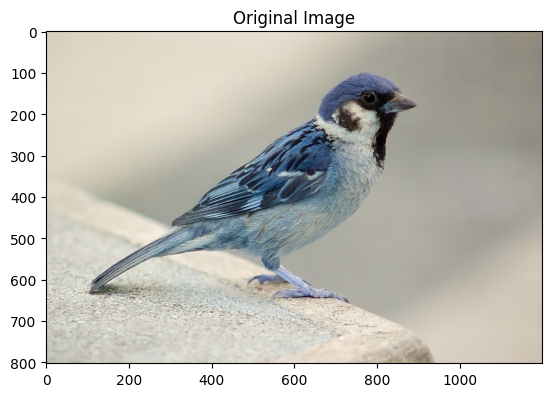

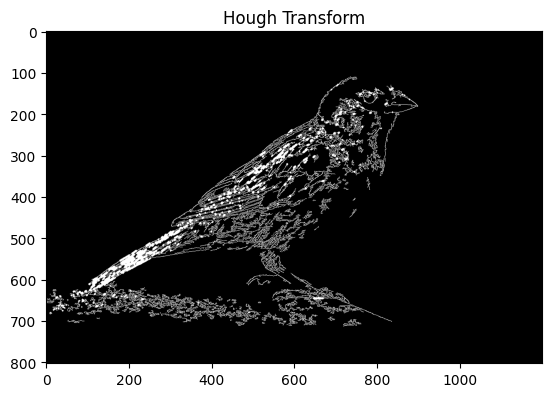

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
test=cv2.imread('imgg.jpg', cv2.IMREAD_COLOR)
img=cv2.cvtColor(test,cv2.COLOR_BGR2GRAY)

plt.title('Original Image')
plt.imshow(test)
plt.show()


# Hough Transform
test=cv2.Canny(img, 100, 400)
lines=cv2.HoughLinesP(test, 1, np.pi/180, 200)

for line in lines:
    x1,y1,x2,y2 =line[0]
    cv2.line(test, (x1,y1),(x2,y2),(255,0,0),3)

plt.title('Hough Transform')
plt.imshow(test, cmap='gray')
plt.show()


practical 1 to 4

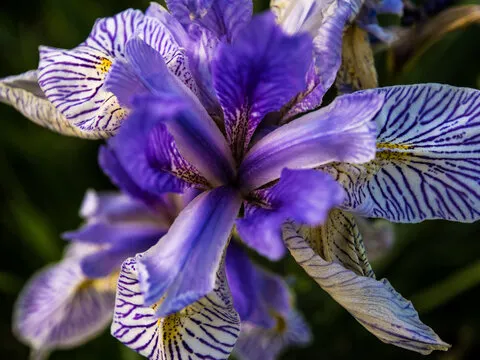

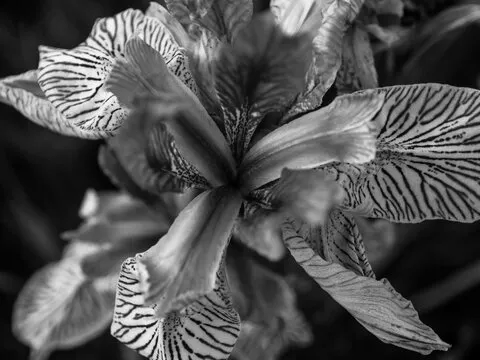

blue_img


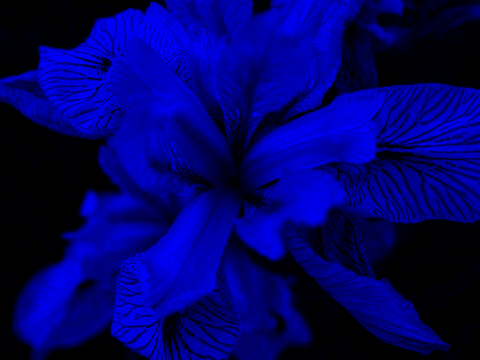

green_img


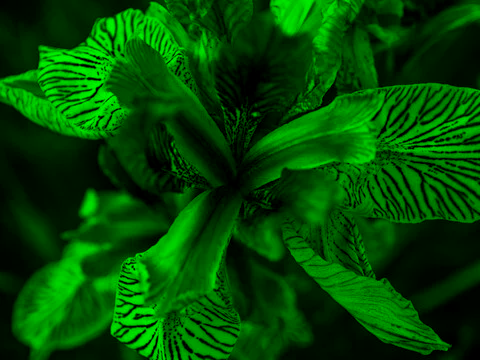

red_img


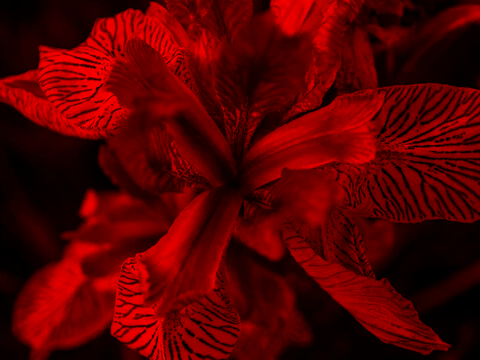

invert_img


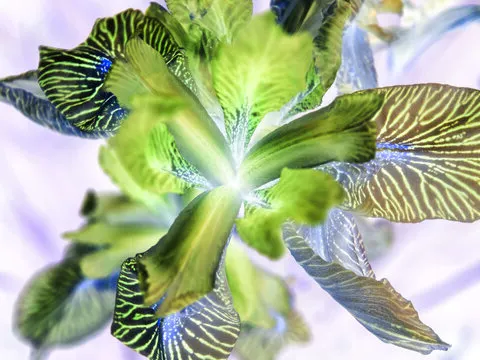

In [ ]:
#Image color
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

image=cv2.imread("/content/img1.jpg")
cv2_imshow(image)
#gray color

gray_image=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
cv2_imshow(gray_image)

# Split image into its color channel
b,g,r=cv2.split(image)

# Zero matrix and ones matrix
zeros=np.zeros(image.shape[:2],dtype="uint8")
ones=np.ones(image.shape[:2],dtype="uint8")*255

blue_img=cv2.merge([b,zeros,zeros])
green_img=cv2.merge([zeros,g,zeros])
red_img=cv2.merge([zeros,zeros,r])
invert_img=cv2.merge([ones-b,ones-g,ones-r])

print("blue_img")
cv2_imshow(blue_img)
print("green_img")
cv2_imshow(green_img)
print("red_img")
cv2_imshow(red_img)
print("invert_img")
cv2_imshow(invert_img)

Input Image 1:



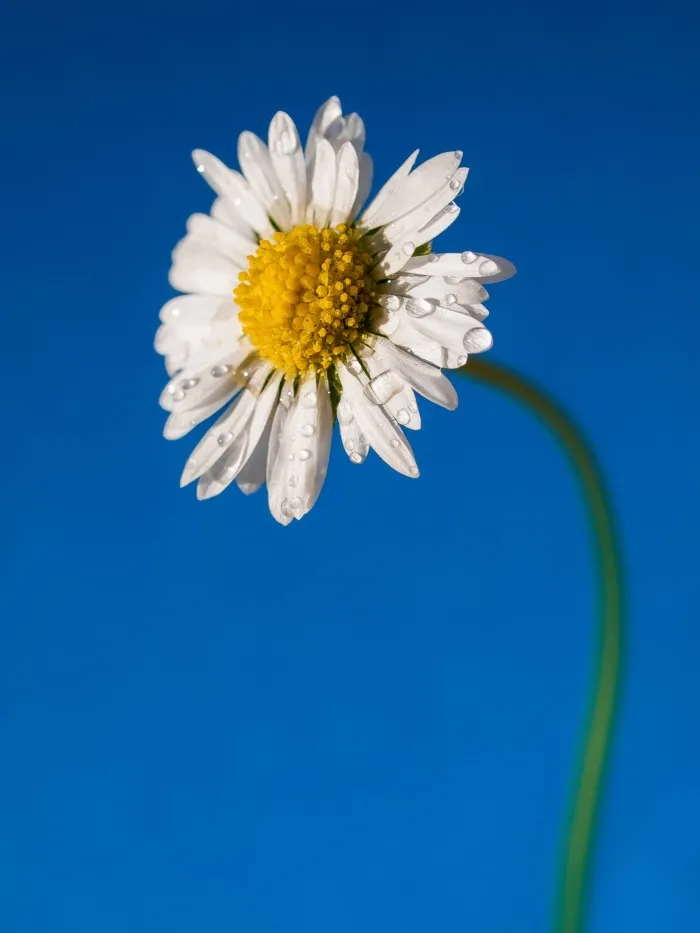


Input Image 2:



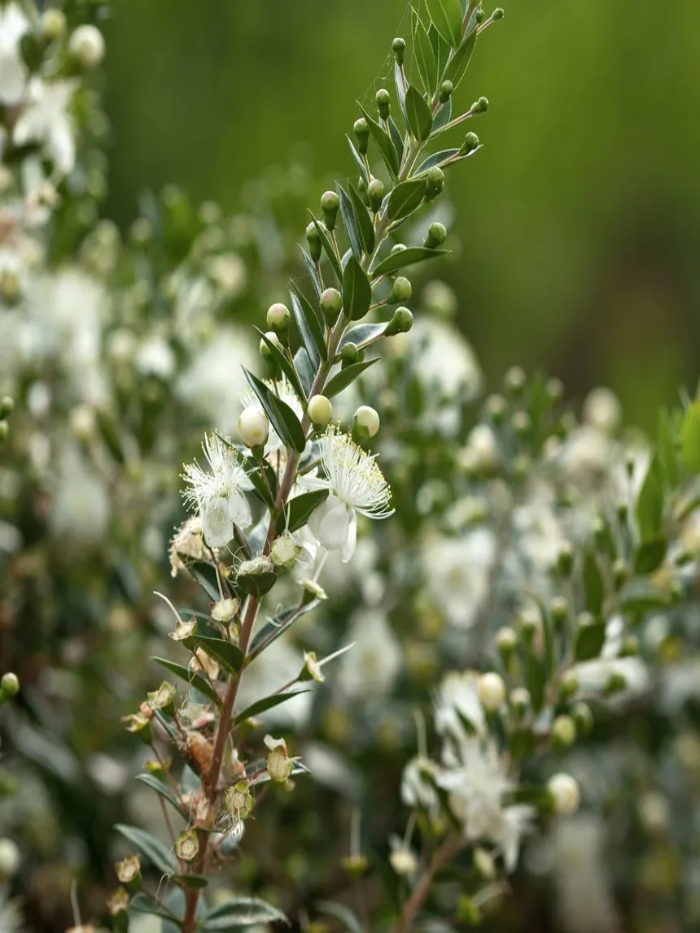


Output Image:



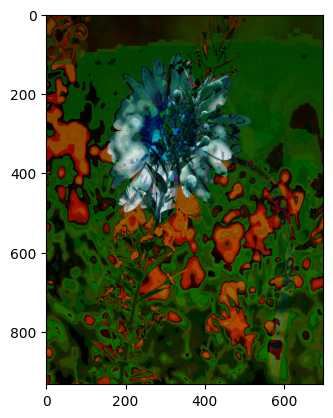

In [ ]:
#Addition
i1 = cv2.imread("/content/MV1.jpg")
i2 = cv2.imread("/content/MV2.jpg")

# Resize i2 to match the dimensions of i1
i2 = cv2.resize(i2, (i1.shape[1], i1.shape[0]))

method1 = cv2.add(i1,i2) #subtract, multiply , division
print("Input Image 1:\n")
cv2_imshow(i1)
print("\nInput Image 2:\n")
cv2_imshow(i2)
print("\nOutput Image:\n")



plt.imshow(method1)

logic_and = cv2.bitwise_and(i1,i2,mask=None)   # not , xor,
plt.imshow(logic_and)

#Nand
logic_and = cv2.bitwise_and(l1,l2,mask=None)
logic_nand = cv2.bitwise_not(logic_and)
print("Nand:\n")
cv2_imshow(logic_nand)

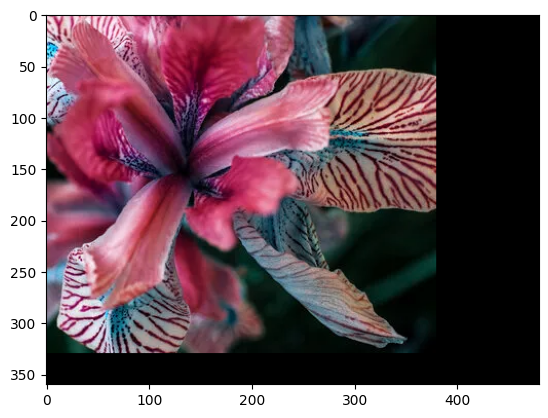

In [ ]:
img1=cv2.imread("/content/img1.jpg")

a=img1
#scaling
res = cv2.resize(a,None,fx=2, fy=2, interpolation = cv2.INTER_CUBIC)

height, width = a.shape[:2]
res = cv2.resize(a,(2*width, 2*height), interpolation = cv2.INTER_CUBIC)

plt.imshow(res)

#translation
rows, cols, ch = a.shape

matrix_trans = np.float32([[1, 0, -100], [0, 1, -30]])
translated_img = cv2.warpAffine(a, matrix_trans, (cols, rows))

plt.imshow(translated_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

#rotation
rows, cols, ch = a.shape

matrix_rotated = cv2.getRotationMatrix2D((cols/2, rows/2), 90, 0.6)
rotated_img = cv2.warpAffine(a, matrix_rotated, (cols, rows))

plt.imshow(rotated_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

#Affine transforms
rows,cols,ch = a.shape

pt1 = np.float32([[40,40],[200,40],[40,200]])
pt2 = np.float32([[10,100],[200,50],[100,250]])

matrix_aff = cv2.getAffineTransform(pt1,pt2)
dst = cv2.warpAffine(a,matrix_aff,(cols,rows))

plt.subplot(121),plt.imshow(a),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')
plt.show()

#3D trasnform
rows,cols,ch = a.shape

pt1 = np.float32([[50,65],[370,52],[30,387],[390,390]])
pt2 = np.float32([[0,0],[310,0],[0,310],[310,310]])

matrix_aff = cv2.getPerspectiveTransform(pt1,pt2)
dst = cv2.warpPerspective(a,matrix_aff,(cols,rows))

plt.subplot(121),plt.imshow(a),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')
plt.show()

#shearing
rows, cols, dim = a.shape

M = np.float32([[1, 0.5, 0],
[0, 1 , 0],
[0, 0 , 1]])

sheared_img = cv2.warpPerspective(a,M,(int(cols*1.5),int(rows*1.5)))

plt.axis('off')

plt.imshow(sheared_img)
plt.show()


#mirror scaling
rows, cols, dim = a.shape

M = np.float32([[1, 0, 0 ],
[0, -1, rows],
[0, 0, 1 ]])

reflected_img = cv2.warpPerspective(a,M,(int(cols),int(rows)))

plt.axis('off')

plt.imshow(reflected_img)
plt.show()


Neighbours

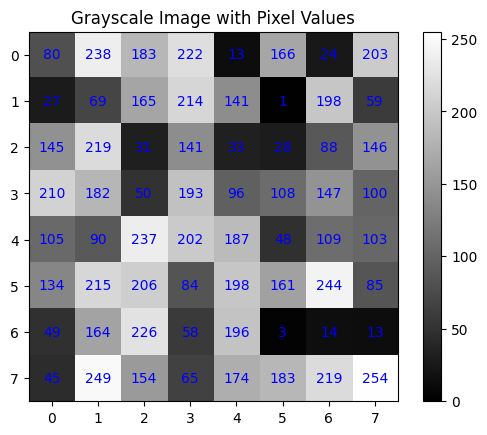

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sz = 8
image = np.random.randint(0, 255, size=(sz, sz))

# Display grayscale image with pixel values
plt.imshow(image, cmap='gray', vmin=0, vmax=255)

# Annotate each pixel with its value
for i in range(sz):
    # Indented block for the outer loop
    for j in range(sz):
        # Indented block for the inner loop
        plt.text(j, i, str(image[i, j]), ha='center', va='center', color='blue')

plt.title("Grayscale Image with Pixel Values")
plt.colorbar()  # Add colorbar for reference
plt.show()

Enter the pixel coordinates (x y): 2 4
Chosen Pixel Coordinates: (2, 4)
Chosen Pixel Value: 97
Four Neighbors: [(1, 4), (3, 4), (2, 3), (2, 5)]
Eight Neighbors: [(1, 4), (3, 4), (2, 3), (2, 5), (1, 3), (1, 5), (3, 3), (3, 5)]


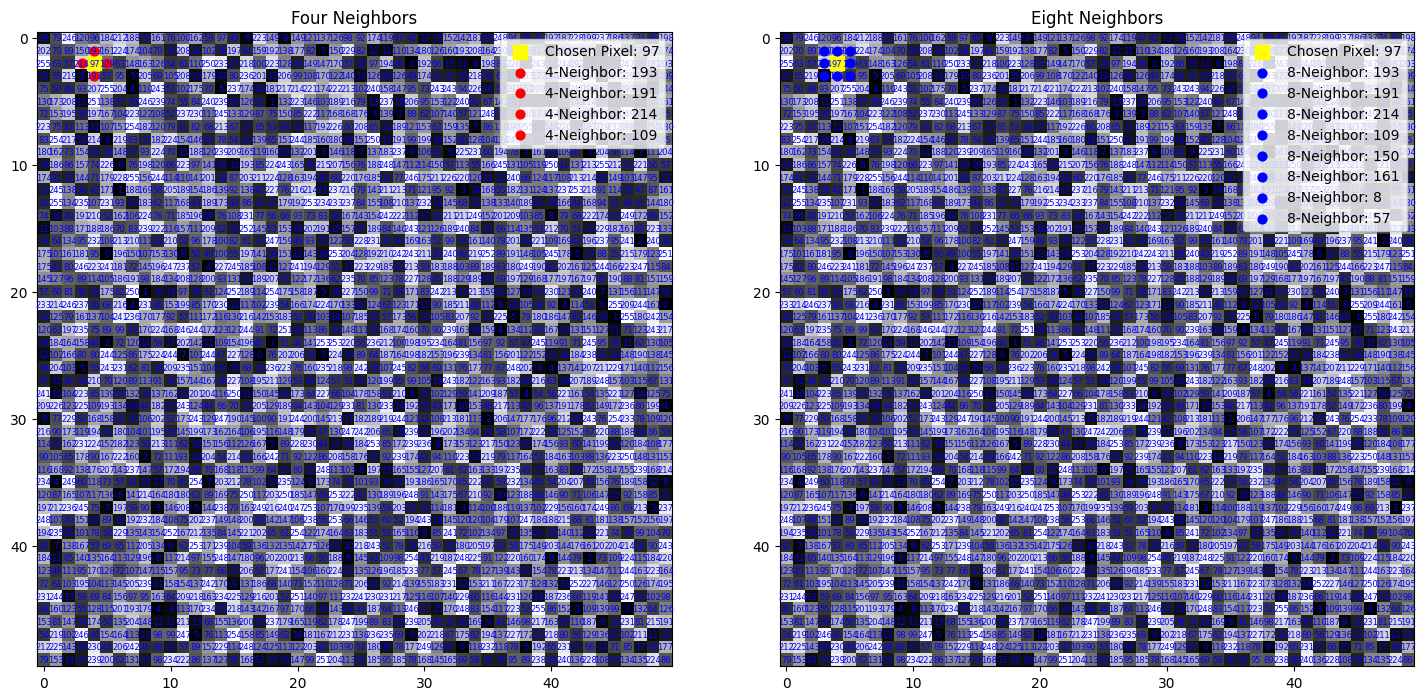

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define functions to get 4-neighbors and 8-neighbors
def get4(x, y, img):
    neigh = []
    if x > 0:
        neigh.append((x-1, y))  # Top
    if x < img.shape[0] - 1:
        neigh.append((x+1, y))  # Bottom
    if y > 0:
        neigh.append((x, y-1))  # Left
    if y < img.shape[1] - 1:
        neigh.append((x, y+1))  # Right
    return neigh

def get8(x, y, img):
    neigh = get4(x, y, img)  # Start with 4-neighbors
    if x > 0 and y > 0:
        neigh.append((x-1, y-1))  # Top-left
    if x > 0 and y < img.shape[1] - 1:
        neigh.append((x-1, y+1))  # Top-right
    if x < img.shape[0] - 1 and y > 0:
        neigh.append((x+1, y-1))  # Bottom-left
    if x < img.shape[0] - 1 and y < img.shape[1] - 1:
        neigh.append((x+1, y+1))  # Bottom-right
    return neigh

# Generate a random grayscale image
sz = 50  # Size of the image (50x50)
image = np.random.randint(0, 256, size=(sz, sz))  # Random values between 0-255

# Input pixel coordinates from the user
x, y = [int(i) for i in input("Enter the pixel coordinates (x y): ").split()]

if x >= sz or y >= sz or x < 0 or y < 0:
    print("Invalid pixel coordinates. Please enter values within the image bounds.")
else:
    print(f"Chosen Pixel Coordinates: ({x}, {y})")
    print(f"Chosen Pixel Value: {image[x, y]}")

    # Get neighbors
    neigh4 = get4(x, y, image)
    neigh8 = get8(x, y, image)

    print(f"Four Neighbors: {neigh4}")
    print(f"Eight Neighbors: {neigh8}")

    # Visualization
    plt.figure(figsize=(15, 7))

    # Plot 4-neighbors
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.scatter(y, x, color='yellow', marker='s', s=100, label=f'Chosen Pixel: {image[x, y]}')
    for xx, yy in neigh4:
        plt.scatter(yy, xx, color='red', marker='o', s=40, label=f'4-Neighbor: {image[xx, yy]}')
    plt.legend(loc='upper right')
    plt.title('Four Neighbors')
    for i in range(sz):
        for j in range(sz):
            plt.text(j, i, str(image[i, j]), ha='center', va='center', fontsize=6, color='blue')

    # Plot 8-neighbors
    plt.subplot(1, 2, 2)
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.scatter(y, x, color='yellow', marker='s', s=100, label=f'Chosen Pixel: {image[x, y]}')
    for xx, yy in neigh8:
        plt.scatter(yy, xx, color='blue', marker='o', s=40, label=f'8-Neighbor: {image[xx, yy]}')
    plt.legend(loc='upper right')
    plt.title('Eight Neighbors')
    for i in range(sz):
        for j in range(sz):
            plt.text(j, i, str(image[i, j]), ha='center', va='center', fontsize=6, color='blue')

    plt.tight_layout()
    plt.show()


Enter the pixel coordinates (x y): 2 4
Chosen Pixel Coordinates: (2, 4)
Chosen Pixel Value: 80
Diagonal Neighbors of pixel (2, 4): [(1, 3), (1, 5), (3, 3), (3, 5)]


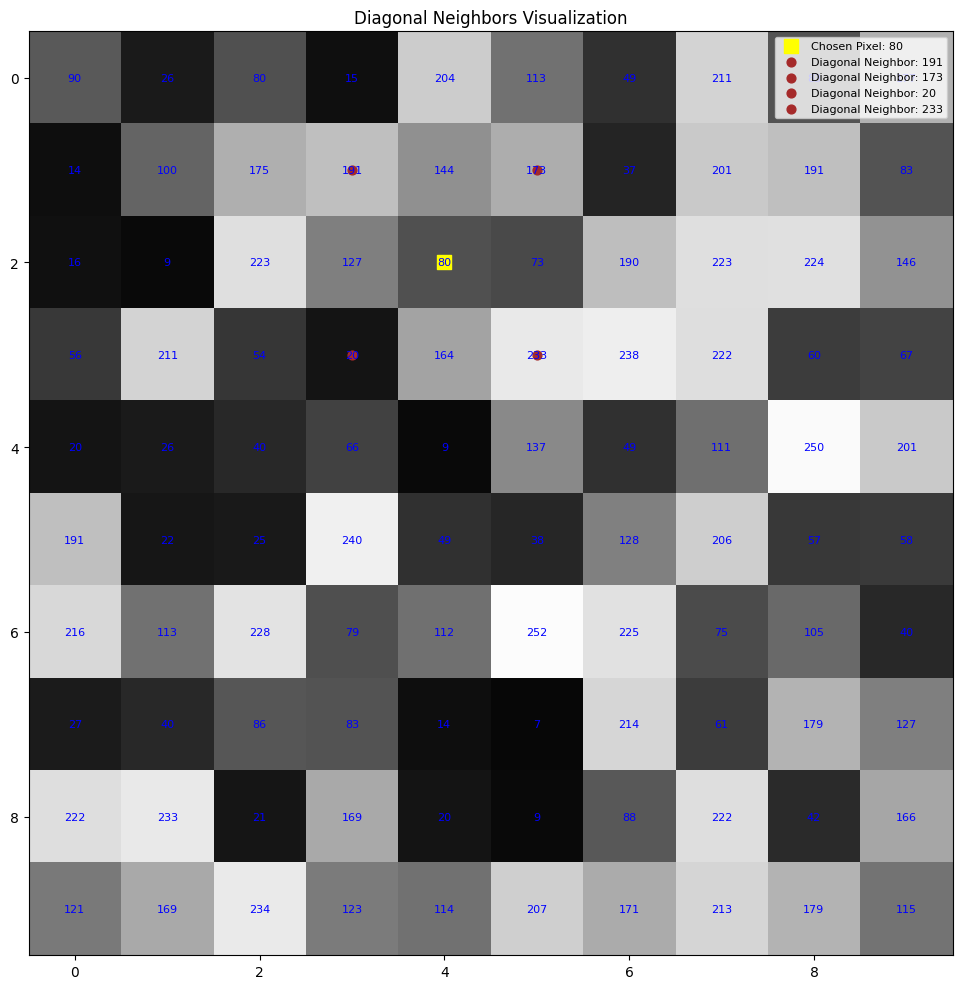

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a random image
sz = 10  # Define the size of the image (10x10 for demonstration)
image = np.random.randint(0, 256, size=(sz, sz))  # Random grayscale image

# Function to get diagonal neighbors
def get_diagonal(x, y, img):
    neigh = []
    if x > 0 and y > 0:
        neigh.append((x-1, y-1))  # Top-left
    if x > 0 and y < img.shape[1] - 1:
        neigh.append((x-1, y+1))  # Top-right
    if x < img.shape[0] - 1 and y > 0:
        neigh.append((x+1, y-1))  # Bottom-left
    if x < img.shape[0] - 1 and y < img.shape[1] - 1:
        neigh.append((x+1, y+1))  # Bottom-right
    return neigh

# User input for pixel coordinates
x, y = [int(i) for i in input("Enter the pixel coordinates (x y): ").split()]

# Validate the input
if x >= sz or y >= sz or x < 0 or y < 0:
    print("Invalid syntax or positions. Please enter valid pixel coordinates.")
else:
    # Get diagonal neighbors
    dia_neigh = get_diagonal(x, y, image)

    # Print results
    print(f'Chosen Pixel Coordinates: ({x}, {y})')
    print(f'Chosen Pixel Value: {image[x, y]}')
    print(f'Diagonal Neighbors of pixel ({x}, {y}): {dia_neigh}')

    # Visualization
    plt.figure(figsize=(10, 10))
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.scatter(y, x, color='yellow', marker='s', s=100, label=f'Chosen Pixel: {image[x, y]}')

    # Highlight diagonal neighbors
    for xx, yy in dia_neigh:
        plt.scatter(yy, xx, color='brown', marker='o', s=40, label=f'Diagonal Neighbor: {image[xx, yy]}')

    # Add pixel values to the plot
    for i in range(sz):
        for j in range(sz):
            plt.text(j, i, str(image[i, j]), ha='center', va='center', color='blue', fontsize=8)

    # Configure legend and title
    plt.legend(loc='upper right', fontsize=8)
    plt.title("Diagonal Neighbors Visualization")
    plt.tight_layout()
    plt.show()


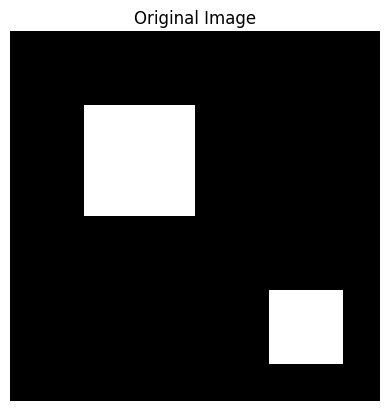

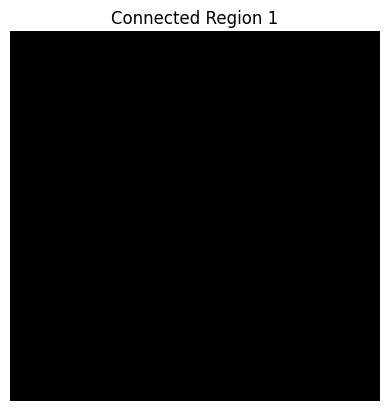

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def dfs(image, visited, x, y, connected_pixels):
    # Base case: Check for boundaries and already visited pixels
    if x < 0 or x >= image.shape[1] or y < 0 or y >= image.shape[0] or visited[y, x]:
        return

    # Mark the pixel as visited and add to connected pixels
    visited[y, x] = True
    connected_pixels.append((x, y))

    # Define 8-connectivity neighbors
    neighbors = [
        (x-1, y-1), (x, y-1), (x+1, y-1),
        (x-1, y),             (x+1, y),
        (x-1, y+1), (x, y+1), (x+1, y+1)
    ]

    # Recurse for all neighbors
    for neighbor_x, neighbor_y in neighbors:
        dfs(image, visited, neighbor_x, neighbor_y, connected_pixels)

def find_connected_regions(image):
    # Initialize visited matrix with the same shape as the image
    visited = np.zeros_like(image, dtype=bool)
    regions = []  # List to store all connected regions

    # Traverse the entire image
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            # If a white pixel (255) is unvisited, start a DFS
            if image[y, x] == 255 and not visited[y, x]:
                connected_pixels = []
                dfs(image, visited, x, y, connected_pixels)
                regions.append(connected_pixels)

    return regions

# Create a sample grayscale binary image
width, height = 10, 10
gray_image = np.zeros((height, width), dtype=np.uint8)

# Add two connected regions
gray_image[2:5, 2:5] = 255  # First region
gray_image[7:9, 7:9] = 255  # Second region

# Find connected regions
connected_regions = find_connected_regions(gray_image)

# Display the original image
plt.imshow(gray_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

# Display each connected region
for i, region in enumerate(connected_regions):
    region_mask = np.zeros_like(gray_image)  # Create a mask for the region
    for x, y in region:
        region_mask[y, x] = 255  # Mark the pixels in the mask

    plt.imshow(region_mask, cmap='gray')
    plt.title(f'Connected Region {i+1}')
    plt.axis('off')
    plt.show()


In [ ]:
import numpy as np

def compute_distances(pixel1, pixel2):
    x1, y1 = pixel1
    x2, y2 = pixel2

    # Euclidean Distance
    euclidean_distance = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    # Cityblock (Manhattan) Distance
    cityblock_distance = abs(x2 - x1) + abs(y2 - y1)

    # Chessboard Distance
    chessboard_distance = max(abs(x2 - x1), abs(y2 - y1))

    return {
        "Euclidean": euclidean_distance,
        "Cityblock": cityblock_distance,
        "Chessboard": chessboard_distance
    }

# Example usage
pixel1 = (3, 5)  # Example pixel coordinates
pixel2 = (7, 1)

# Compute distances
distances = compute_distances(pixel1, pixel2)

# Print results
print("Distances between", pixel1, "and", pixel2)
for key, value in distances.items():
    print(f"{key} Distance: {value}")


SIFT SURF

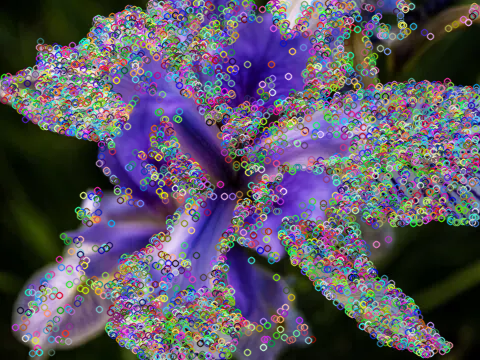

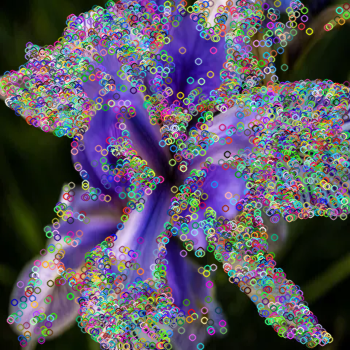

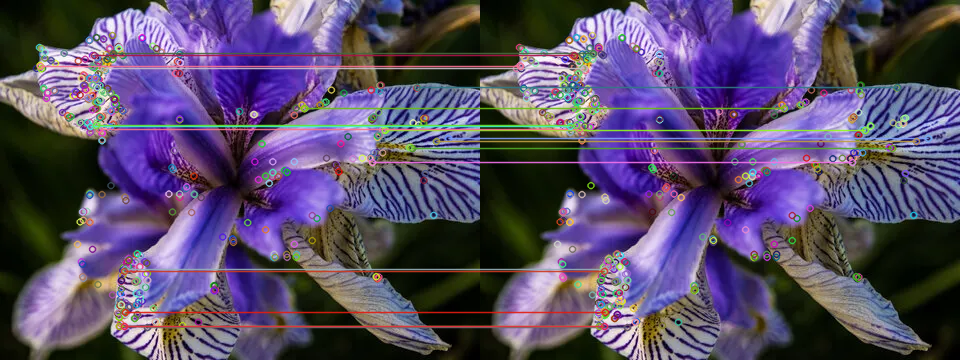

NameError: name 'image3' is not defined

In [ ]:
#############3 fast
image1=cv2.imread('img1.jpg')
image2=cv2.resize(image1,(350,350))

fast = cv2.FastFeatureDetector_create()
kp1=fast.detect(image1,None)
kp2=fast.detect(image2,None)

output_image=cv2.drawKeypoints(image1,kp1,None)
output_image1=cv2.drawKeypoints(image2,kp2,None)

cv2_imshow(output_image)
cv2_imshow(output_image1)



###########  orb

orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(image1, None)
kp2, des2 = orb.detectAndCompute(image1, None)

matches=cv2.BFMatcher(cv2.NORM_L2,crossCheck=True)
matches=matches.match(des1,des2)
matches=sorted(matches,key=lambda x:x.distance)

img_matches=cv2.drawMatches(image1,kp1,image1,kp2,matches[:20],None)
cv2_imshow(img_matches)

cv2.waitKey(0)
cv2.destroyAllWindows()



################ brief
brief=cv2.xfeatures2d.BriefDescriptorExtractor_create()

kp1,des1=brief.compute(image1,kp1)
kp2,des2=brief.compute(image2,kp2)

output_image=cv2.drawKeypoints(image3,kp1,None)
output_image1=cv2.drawKeypoints(image4,kp2,None)

cv2_imshow(output_image)
cv2_imshow(output_image1)

matches=cv2.BFMatcher(cv2.NORM_L2,crossCheck=True)
matches=matches.match(des1,des2)
matches=sorted(matches,key=lambda x:x.distance)

img_matches=cv2.drawMatches(image3,kp1,image1,kp2,matches[:20],None)
cv2_imshow(img_matches)

cv2.waitKey(0)
cv2.destroyAllWindows()


#####################   shift
sift = cv2.SIFT_create()

keypoints, des1 = sift.detectAndCompute(image3, None)
keypoints1, des2 = sift.detectAndCompute(image4, None)

output_image1 = cv2.drawKeypoints(image3, keypoints, None)
output_image2 = cv2.drawKeypoints(image4, keypoints1, None)

cv2_imshow(output_image1)
cv2_imshow(output_image2)

matches=cv2.BFMatcher(cv2.NORM_L2,crossCheck=True)
matches=matches.match(des1,des2)
matches=sorted(matches,key=lambda x:x.distance)

img_matches=cv2.drawMatches(image3,keypoints,image1,keypoints1,matches[:20],None)
cv2_imshow(img_matches)


cv2.waitKey(0)
cv2.destroyAllWindows()




